
========== Setting 1 ==========
Best Utility = 0.339615
Average Utility = 0.339615 ± 0.000000
Best n = 50
Number of validators m = 25
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 0.44 seconds

========== Setting 2 ==========
Best Utility = 0.342963
Average Utility = 0.342963 ± 0.000000
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 0.61 seconds


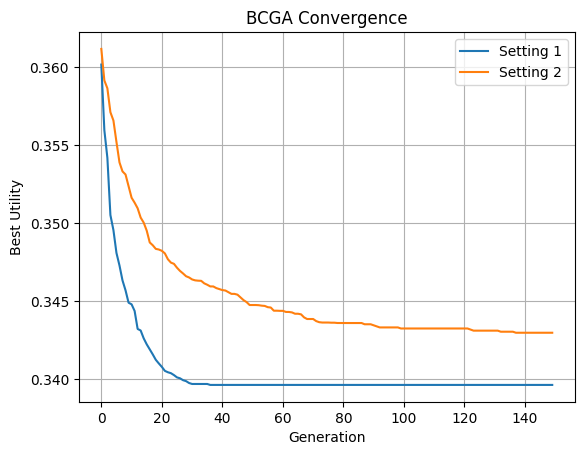

In [1]:
"""
BCGA (Binary Coded Genetic Algorithm) for Blockchain Configuration Optimization
Follows the pseudo-algorithm: (µ+λ) selection, tournament, single-point crossover, bitwise mutation.
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS (set at top) =========================

# Problem parameters (common to both settings)
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# GA parameters
POP_SIZE = 100             # population size (µ)
GENERATIONS = 150         # number of generations (T)
CROSSOVER_PROB = 0.8      # probability of crossover (pc)
MUTATION_PROB = 0.1      # bitwise mutation probability (pm)
TOURNAMENT_SIZE = 3       # tournament selection size (k)
N_BITS_N = 9              # bits to encode n (transactions per block)

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        # Setting 1 or 2
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)                 # ascending
        sorted_desc = sorted(self.x, reverse=True) # descending
        
        # ----- Cost bounds (C = sum(x_i) / n) -----
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X      # smallest sum / largest n
        self.C_max = sum_all_M / self.t           # largest sum / smallest n
        
        # ----- Security bounds (eta = theta * m^q) -----
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # ----- Latency bounds (L = nB/RD + max(K/x_i) + psi * n * B * m + O/RU) -----
        # L_min: use fastest v validators -> max(K/x_i) = K / (v-th fastest = sorted_desc[v-1])
        #        and m = v
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        # L_max: use slowest validator (min x_i) and m = M
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (fitness) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        # Constraints check
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        # Cost = sum(x_i) / n
        C = sum(self.x[i] for i in selected_indices) / n
        
        # Security = theta * m^q
        eta = THETA * (m ** Q)
        
        # Latency
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        # Normalized components
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)  # maximize security
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        # Final utility (average of three normalized objectives)
        return (C_norm + eta_norm + L_norm) / 3


# ========================= GA UTILITY FUNCTIONS =========================


def decode_binary(bits, low, high):
    """Decode a binary list to a float in [low, high] using linear scaling."""
    int_val = int(''.join(map(str, bits)), 2)
    max_int = 2 ** len(bits) - 1
    return low + (int_val / max_int) * (high - low)

def create_individual(problem):
    """
    Create a random individual (binary chromosome).
    Structure: [9 bits for n] + [M bits for validator selection]
    """
    # Bits for n (transactions per block)
    bits_n = [random.randint(0, 1) for _ in range(N_BITS_N)]
    # Validator mask: at least v and at most M ones (feasible by construction)
    m = random.randint(problem.v, problem.M)
    selected = random.sample(range(problem.M), m)
    bits_m = [1 if i in selected else 0 for i in range(problem.M)]
    return bits_n + bits_m

def decode_individual(individual, problem):
    """
    Convert binary chromosome to actual decision variables and compute fitness.
    Returns: (selected_validators, n, fitness)
    """
    bits_n = individual[:N_BITS_N]
    bits_m = individual[N_BITS_N:]
    # Decode n
    n_float = decode_binary(bits_n, problem.t, problem.X)
    n = int(round(n_float))
    n = max(problem.t, min(problem.X, n))
    # Decode validator selection
    selected = [i for i, bit in enumerate(bits_m) if bit == 1]
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness



def tournament_selection(population, fitnesses, k):
    """Select one individual using tournament selection (minimization)."""
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]  # return a copy

def single_point_crossover(parent1, parent2, prob):
    """Perform single-point crossover with given probability."""
    if random.random() < prob:
        point = random.randint(1, len(parent1) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    else:
        return parent1[:], parent2[:]

def bitwise_mutation(individual, prob):
    """Flip each bit with probability prob."""
    return [bit if random.random() >= prob else 1 - bit for bit in individual]


# ========================= MAIN GA (µ+λ) =========================

def bcga(problem):
    """
    Binary Coded Genetic Algorithm following pseudo-algorithm:
    - Initialize random population of size POP_SIZE
    - Evaluate fitness
    - For each generation:
        - Tournament selection to choose parents
        - Crossover and mutation to create λ = POP_SIZE offspring
        - Combine parents + offspring (µ+λ)
        - Select best µ individuals for next generation
    """
    # Initialization
    population = [create_individual(problem) for _ in range(POP_SIZE)]
    fitnesses = [decode_individual(ind, problem)[2] for ind in population]
    
    best_fitness = float('inf')
    best_solution = None
    history = []
    
    for gen in range(GENERATIONS):
        # ----- Generate offspring (λ = POP_SIZE) -----
        offspring = []
        # Each iteration creates 2 offspring, so we need POP_SIZE//2 iterations
        while len(offspring) < POP_SIZE:
            # Tournament selection
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            # Crossover
            c1, c2 = single_point_crossover(p1, p2, CROSSOVER_PROB)
            # Mutation
            c1 = bitwise_mutation(c1, MUTATION_PROB)
            c2 = bitwise_mutation(c2, MUTATION_PROB)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        
        # Evaluate offspring fitness
        offspring_fitnesses = [decode_individual(ind, problem)[2] for ind in offspring]
        
        # ----- (µ+λ) selection: combine parents and offspring -----
        combined_pop = population + offspring
        combined_fitness = fitnesses + offspring_fitnesses
        
        # Select best POP_SIZE individuals (minimization)
        sorted_indices = np.argsort(combined_fitness)[:POP_SIZE]
        population = [combined_pop[i] for i in sorted_indices]
        fitnesses = [combined_fitness[i] for i in sorted_indices]
        
        # Track best solution
        gen_best_fit = min(fitnesses)
        if gen_best_fit < best_fitness:
            best_fitness = gen_best_fit
            best_idx = fitnesses.index(gen_best_fit)
            best_solution = decode_individual(population[best_idx], problem)
        
        history.append(best_fitness)
    
    return best_fitness, best_solution, history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run BCGA multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = bcga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n, _ = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('BCGA Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()


========== Setting 1 ==========
Best Utility = 0.349995
Average Utility = 0.361379 ± 0.006429
Best n = 50
Number of validators m = 23
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 0.97 seconds

========== Setting 2 ==========
Best Utility = 0.346969
Average Utility = 0.362211 ± 0.006438
Best n = 50
Number of validators m = 38
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 1.59 seconds


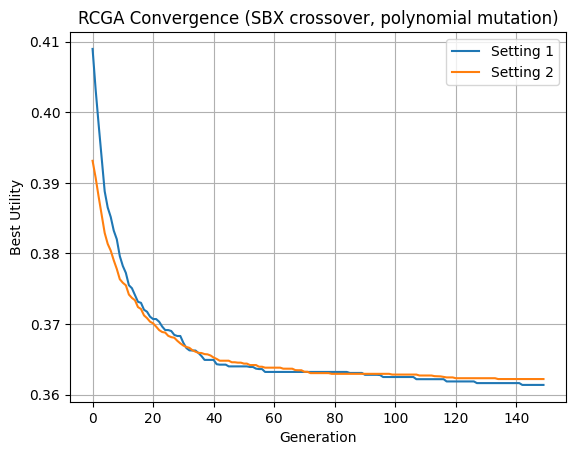

In [2]:

"""
RCGA (Real-Coded Genetic Algorithm) for Blockchain Configuration Optimization
Follows pseudo-algorithm:
- Tournament selection
- SBX crossover (with distribution index ηc)
- Polynomial mutation (with distribution index ηm)
- (µ+λ) selection
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# GA parameters (common for both settings)
POP_SIZE = 100             # population size (µ)
GENERATIONS = 150         # number of generations (T)
CROSSOVER_PROB = 0.8      # probability of crossover (pc)
MUTATION_PROB = 0.1      # probability of mutation (pm)
TOURNAMENT_SIZE = 3       # tournament size (k)
ETA_C = 20                # distribution index for SBX crossover (ηc)
ETA_M = 20                # distribution index for polynomial mutation (ηm)

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        
        # Cost bounds
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X
        self.C_max = sum_all_M / self.t
        
        # Security bounds
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # Latency bounds
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (fitness) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        return (C_norm + eta_norm + L_norm) / 3


# ========================= RCGA OPERATORS =========================

def decode_individual(chromosome, problem):
    """
    Decode a real-coded chromosome into decision variables.
    Chromosome structure: [0] -> n (scaled [t, X])
                         [1..M] -> validator selection probabilities [0,1]
    Returns: (selected_validators, n, fitness)
    """
    # Decode n (first gene)
    n_gene = chromosome[0]
    n = int(round(n_gene))
    n = max(problem.t, min(problem.X, n))
    
    # Decode validator mask: select indices where gene > 0.5
    mask = chromosome[1:1+problem.M]
    selected = [i for i, val in enumerate(mask) if val > 0.5]
    
    # Ensure v <= m <= M
    if len(selected) < problem.v:
        # Add missing validators from those not selected (lowest mask values first)
        not_selected = [(i, mask[i]) for i in range(problem.M) if mask[i] <= 0.5]
        not_selected.sort(key=lambda x: x[1], reverse=True)  # highest among <0.5
        needed = problem.v - len(selected)
        for i in range(min(needed, len(not_selected))):
            selected.append(not_selected[i][0])
    elif len(selected) > problem.M:
        # This should not happen, but just in case: truncate
        selected = selected[:problem.M]
    
    # Remove duplicates (if any) and sort for consistency
    selected = sorted(set(selected))
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def tournament_selection(population, fitnesses, k):
    """Tournament selection for minimization."""
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx].copy()

def sbx_crossover(parent1, parent2, eta_c, prob, bounds):
    """
    Simulated Binary Crossover (SBX) with probability prob.
    bounds: list of (low, high) for each variable.
    Returns two offspring.
    """
    if random.random() > prob:
        return parent1.copy(), parent2.copy()
    
    offspring1 = []
    offspring2 = []
    for i in range(len(parent1)):
        u = random.random()
        if u <= 0.5:
            beta = (2 * u) ** (1 / (eta_c + 1))
        else:
            beta = (1 / (2 * (1 - u))) ** (1 / (eta_c + 1))
        
        # Ensure spread factor is not too large
        beta = max(1e-6, min(beta, 1e6))
        
        # Compute children
        low, high = bounds[i]
        y1 = 0.5 * ((1 + beta) * parent1[i] + (1 - beta) * parent2[i])
        y2 = 0.5 * ((1 - beta) * parent1[i] + (1 + beta) * parent2[i])
        
        # Clamp to bounds
        y1 = max(low, min(high, y1))
        y2 = max(low, min(high, y2))
        
        offspring1.append(y1)
        offspring2.append(y2)
    
    return offspring1, offspring2

def polynomial_mutation(individual, eta_m, prob, bounds):
    """
    Polynomial mutation with probability prob.
    Returns mutated individual (may be unchanged).
    """
    if random.random() > prob:
        return individual.copy()
    
    mutated = []
    for i, gene in enumerate(individual):
        low, high = bounds[i]
        delta = min(gene - low, high - gene) / (high - low)
        
        u = random.random()
        if u < 0.5:
            delta_q = (2 * u + (1 - 2 * u) * (1 - delta) ** (eta_m + 1)) ** (1 / (eta_m + 1)) - 1
        else:
            delta_q = 1 - (2 * (1 - u) + 2 * (u - 0.5) * (1 - delta) ** (eta_m + 1)) ** (1 / (eta_m + 1))
        
        delta_q = max(-delta, min(1 - delta, delta_q))
        new_gene = gene + delta_q * (high - low)
        new_gene = max(low, min(high, new_gene))
        mutated.append(new_gene)
    
    return mutated


# ========================= MAIN RCGA =========================

def rcga(problem):
    """
    Real-Coded Genetic Algorithm following the pseudo-algorithm:
    - Initialize random population of size POP_SIZE
    - Evaluate fitness
    - For each generation:
        - Tournament selection to choose parents
        - SBX crossover to create λ = POP_SIZE offspring
        - Polynomial mutation on offspring
        - Evaluate offspring
        - (µ+λ) selection: combine parents and offspring, keep best µ
    """
    # Bounds for each variable: first for n [t, X], then M variables [0,1]
    bounds = [(problem.t, problem.X)] + [(0.0, 1.0) for _ in range(problem.M)]
    
    # Initialize population uniformly in bounds
    population = []
    for _ in range(POP_SIZE):
        ind = [random.uniform(low, high) for low, high in bounds]
        population.append(ind)
    
    # Evaluate initial population
    fitnesses = []
    for ind in population:
        _, _, fit = decode_individual(ind, problem)
        fitnesses.append(fit)
    
    best_fitness = float('inf')
    best_solution = None
    history = []
    
    for gen in range(GENERATIONS):
        # ----- Generate offspring (λ = POP_SIZE) -----
        offspring = []
        # Each iteration creates 2 offspring via crossover
        while len(offspring) < POP_SIZE:
            # Tournament selection
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            # SBX crossover
            c1, c2 = sbx_crossover(p1, p2, ETA_C, CROSSOVER_PROB, bounds)
            # Polynomial mutation
            c1 = polynomial_mutation(c1, ETA_M, MUTATION_PROB, bounds)
            c2 = polynomial_mutation(c2, ETA_M, MUTATION_PROB, bounds)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        
        # Evaluate offspring fitness
        offspring_fitness = []
        for ind in offspring:
            _, _, fit = decode_individual(ind, problem)
            offspring_fitness.append(fit)
        
        # ----- (µ+λ) selection: combine parents and offspring, keep best µ -----
        combined_pop = population + offspring
        combined_fit = fitnesses + offspring_fitness
        # Sort by fitness (minimization)
        sorted_indices = np.argsort(combined_fit)[:POP_SIZE]
        population = [combined_pop[i] for i in sorted_indices]
        fitnesses = [combined_fit[i] for i in sorted_indices]
        
        # Track best solution
        gen_best_fit = min(fitnesses)
        if gen_best_fit < best_fitness:
            best_fitness = gen_best_fit
            best_idx = fitnesses.index(gen_best_fit)
            best_solution = decode_individual(population[best_idx], problem)
        
        history.append(best_fitness)
    
    return best_fitness, best_solution, history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run RCGA multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = rcga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n, _ = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('RCGA Convergence (SBX crossover, polynomial mutation)')
    plt.legend()
    plt.grid(True)
    plt.show()


========== Setting 1 ==========
Best Utility = 0.339615
Average Utility = 0.342976 ± 0.003777
Best n = 50
Number of validators m = 25
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 0.82 seconds

========== Setting 2 ==========
Best Utility = 0.342963
Average Utility = 0.349949 ± 0.003864
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 1.15 seconds


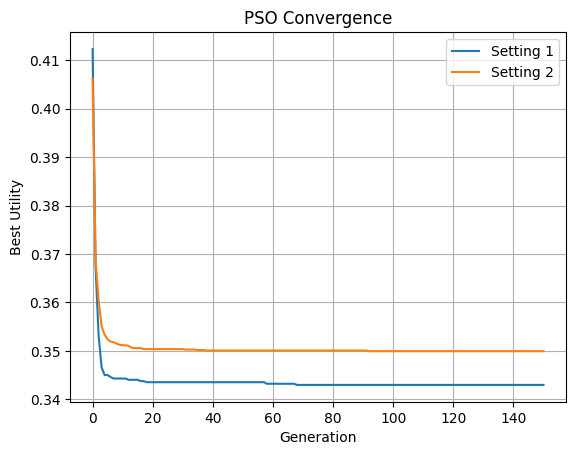

In [3]:
"""
PSO (Particle Swarm Optimization) for Blockchain Configuration Optimization
Follows pseudo-algorithm:
- Initialize random population (positions) and velocities within bounds
- Evaluate fitness
- Set pbest = positions, gbest = best position
- For each generation:
    - Update velocity and position for each particle
    - Bound positions
    - Evaluate new fitness
    - Update pbest and gbest
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# PSO parameters
POP_SIZE = 100             # population size (Np)
GENERATIONS = 150         # number of generations (T)
W = 0.7                   # inertia weight
C1 = 1.5                  # cognitive coefficient
C2 = 1.5                  # social coefficient

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        
        # Cost bounds
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X
        self.C_max = sum_all_M / self.t
        
        # Security bounds
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # Latency bounds
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (fitness) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        return (C_norm + eta_norm + L_norm) / 3


# ========================= PSO IMPLEMENTATION =========================

def decode_position(position, problem):
    """
    Decode a real-coded position (particle) into decision variables.
    Position structure: [0] -> n (scaled [t, X])
                       [1..M] -> validator selection probabilities [0,1]
    Returns: (selected_validators, n, fitness)
    """
    # Decode n (first dimension)
    n_gene = position[0]
    n = int(round(n_gene))
    n = max(problem.t, min(problem.X, n))
    
    # Decode validator mask: select indices where gene > 0.5
    mask = position[1:1+problem.M]
    selected = [i for i, val in enumerate(mask) if val > 0.5]
    
    # Ensure v <= m <= M
    if len(selected) < problem.v:
        # Add missing validators from those not selected (highest mask values first)
        not_selected = [(i, mask[i]) for i in range(problem.M) if mask[i] <= 0.5]
        not_selected.sort(key=lambda x: x[1], reverse=True)
        needed = problem.v - len(selected)
        for i in range(min(needed, len(not_selected))):
            selected.append(not_selected[i][0])
    elif len(selected) > problem.M:
        selected = selected[:problem.M]
    
    # Remove duplicates and sort
    selected = sorted(set(selected))
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def initialize_population(problem, pop_size):
    """
    Initialize positions and velocities.
    Positions: each particle has (M+1) dimensions:
        - dimension 0: n in [t, X]
        - dimensions 1..M: validator probability in [0,1]
    Velocities: each dimension initialised in [-range/4, range/4] typically.
    """
    positions = []
    velocities = []
    for _ in range(pop_size):
        # Position
        pos = [random.uniform(problem.t, problem.X)]  # n
        pos += [random.uniform(0, 1) for _ in range(problem.M)]  # validator genes
        positions.append(pos)
        
        # Velocity: range for n is (X - t), for validator genes is 1
        vel = [random.uniform(-(problem.X - problem.t)/4, (problem.X - problem.t)/4)]
        vel += [random.uniform(-0.25, 0.25) for _ in range(problem.M)]
        velocities.append(vel)
    
    return positions, velocities

def evaluate_population(positions, problem):
    """Evaluate fitness for all positions."""
    fitnesses = []
    for pos in positions:
        _, _, fit = decode_position(pos, problem)
        fitnesses.append(fit)
    return fitnesses

def update_velocity(velocity, position, pbest, gbest, w, c1, c2):
    """Update velocity for a single particle."""
    new_vel = []
    for d in range(len(position)):
        r1 = random.random()
        r2 = random.random()
        cognitive = c1 * r1 * (pbest[d] - position[d])
        social = c2 * r2 * (gbest[d] - position[d])
        new_vel_d = w * velocity[d] + cognitive + social
        new_vel.append(new_vel_d)
    return new_vel

def update_position(position, velocity, problem):
    """Update position and clamp to bounds."""
    bounds = [(problem.t, problem.X)] + [(0.0, 1.0) for _ in range(problem.M)]
    new_pos = []
    for d in range(len(position)):
        new_val = position[d] + velocity[d]
        low, high = bounds[d]
        new_val = max(low, min(high, new_val))
        new_pos.append(new_val)
    return new_pos

def pso(problem):
    """
    Particle Swarm Optimization algorithm.
    Returns best fitness, best solution (selected validators, n), and convergence history.
    """
    # Step 1: Initialize random population and velocities
    positions, velocities = initialize_population(problem, POP_SIZE)
    
    # Step 2: Evaluate objective function
    fitnesses = evaluate_population(positions, problem)
    
    # Step 3: Assign pbest as positions and fpbest as fitnesses
    pbest = [pos[:] for pos in positions]
    pbest_fitness = fitnesses[:]
    
    # Step 4: Identify global best
    gbest_idx = np.argmin(fitnesses)
    gbest = positions[gbest_idx][:]
    gbest_fitness = fitnesses[gbest_idx]
    
    history = [gbest_fitness]
    
    # Main loop
    for t in range(GENERATIONS):
        for i in range(POP_SIZE):
            # Determine velocity
            velocities[i] = update_velocity(velocities[i], positions[i], pbest[i], gbest, W, C1, C2)
            # Determine new position
            new_pos = update_position(positions[i], velocities[i], problem)
            # Evaluate new fitness
            _, _, new_fitness = decode_position(new_pos, problem)
            # Update population
            positions[i] = new_pos
            fitnesses[i] = new_fitness
            # Update pbest
            if new_fitness < pbest_fitness[i]:
                pbest[i] = new_pos[:]
                pbest_fitness[i] = new_fitness
            # Update gbest
            if new_fitness < gbest_fitness:
                gbest = new_pos[:]
                gbest_fitness = new_fitness
        history.append(gbest_fitness)
    
    # Decode final best solution
    selected, n, _ = decode_position(gbest, problem)
    return gbest_fitness, (selected, n), history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run PSO multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = pso(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('PSO Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()

    


========== Setting 1 ==========
Best Utility = 0.339615
Average Utility = 0.339615 ± 0.000000
Best n = 50
Number of validators m = 25
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 0.47 seconds

========== Setting 2 ==========
Best Utility = 0.342963
Average Utility = 0.342963 ± 0.000000
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 0.65 seconds


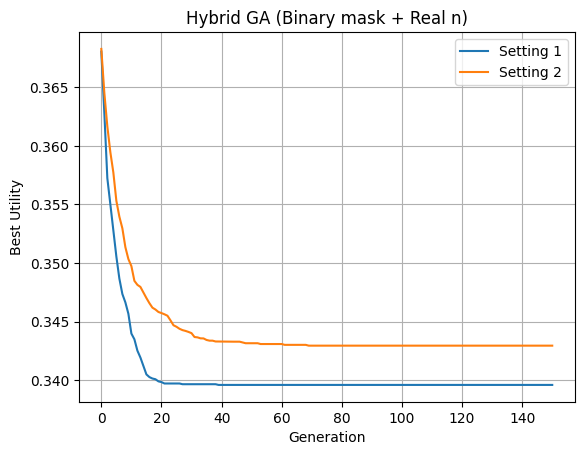

In [4]:
"""
Hybrid GA: Binary for validators (BCGA) + Real for n (RCGA)
- Validator mask: binary string of length M, crossover = single-point, mutation = bitwise
- n: real value in [t, X], crossover = SBX, mutation = polynomial
- Selection: tournament (minimization), (µ+λ) replacement
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4
THETA = 1
O = 0.5
RD = 1.2
RU = 1.3
K = 100
B = 0.5
PSI = 0.001

# GA parameters
POP_SIZE = 100
GENERATIONS = 150
CROSSOVER_PROB = 0.8      # for both parts
MUTATION_PROB_BINARY = 0.1   # bitwise mutation probability
TOURNAMENT_SIZE = 3

# SBX / polynomial mutation parameters (for n)
ETA_C = 20
ETA_M = 20
MUTATION_PROB_REAL = 0.1     # probability to mutate n

# ========================= PROBLEM CLASS (unchanged) =========================

class BlockchainConfig:
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        self.compute_bounds()
    
    def compute_bounds(self):
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        self.C_min = sum(sorted_x[:self.v]) / self.X
        self.C_max = sum(self.x) / self.t
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        self.L_min = (self.t * B / RD + K / sorted_desc[self.v - 1] + PSI * self.t * B * self.v + O / RU)
        self.L_max = (self.X * B / RD + K / min(self.x) + PSI * self.X * B * self.M + O / RU)
    
    def normalize(self, value, min_val, max_val):
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD + max(K_xi) + PSI * n * B * m + O / RU)
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        return (C_norm + eta_norm + L_norm) / 3

# ========================= HYBRID GA =========================

def create_individual(problem):
    """Individual = [real_n] + binary_mask of length M"""
    n = random.uniform(problem.t, problem.X)
    # Validator mask: at least v ones
    m = random.randint(problem.v, problem.M)
    selected = random.sample(range(problem.M), m)
    mask = [1 if i in selected else 0 for i in range(problem.M)]
    return [n] + mask

def decode_individual(individual, problem):
    n = individual[0]
    n = int(round(n))
    n = max(problem.t, min(problem.X, n))
    mask = individual[1:]
    selected = [i for i, bit in enumerate(mask) if bit == 1]
    # Ensure feasibility (should already be, but repair just in case)
    if len(selected) < problem.v:
        # add missing ones (choose from unselected randomly)
        missing = problem.v - len(selected)
        candidates = [i for i, b in enumerate(mask) if b == 0]
        if len(candidates) >= missing:
            selected.extend(random.sample(candidates, missing))
    elif len(selected) > problem.M:
        selected = selected[:problem.M]
    selected = sorted(set(selected))
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def tournament_selection(population, fitnesses, k):
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]

# ----- Binary operators for validator mask -----
def single_point_crossover_mask(parent1_mask, parent2_mask, prob):
    if random.random() < prob:
        point = random.randint(1, len(parent1_mask)-1)
        child1 = parent1_mask[:point] + parent2_mask[point:]
        child2 = parent2_mask[:point] + parent1_mask[point:]
        return child1, child2
    else:
        return parent1_mask[:], parent2_mask[:]

def bitwise_mutation_mask(mask, prob):
    return [bit if random.random() >= prob else 1-bit for bit in mask]

# ----- Real operators for n -----
def sbx_crossover_real(parent1_n, parent2_n, eta_c, prob, low, high):
    if random.random() > prob:
        return parent1_n, parent2_n
    u = random.random()
    if u <= 0.5:
        beta = (2*u) ** (1/(eta_c+1))
    else:
        beta = (1/(2*(1-u))) ** (1/(eta_c+1))
    beta = max(1e-6, min(beta, 1e6))
    y1 = 0.5*((1+beta)*parent1_n + (1-beta)*parent2_n)
    y2 = 0.5*((1-beta)*parent1_n + (1+beta)*parent2_n)
    y1 = max(low, min(high, y1))
    y2 = max(low, min(high, y2))
    return y1, y2

def polynomial_mutation_real(n, eta_m, prob, low, high):
    if random.random() > prob:
        return n
    delta = min(n-low, high-n) / (high-low)
    u = random.random()
    if u < 0.5:
        delta_q = (2*u + (1-2*u)*(1-delta)**(eta_m+1))**(1/(eta_m+1)) - 1
    else:
        delta_q = 1 - (2*(1-u) + 2*(u-0.5)*(1-delta)**(eta_m+1))**(1/(eta_m+1))
    delta_q = max(-delta, min(1-delta, delta_q))
    new_n = n + delta_q*(high-low)
    return max(low, min(high, new_n))

def hybrid_crossover(parent1, parent2, prob_cross, problem):
    """Crossover: separate for n and mask"""
    # n part: SBX
    n1, n2 = sbx_crossover_real(parent1[0], parent2[0], ETA_C, prob_cross, problem.t, problem.X)
    # mask part: single-point binary crossover
    mask1, mask2 = single_point_crossover_mask(parent1[1:], parent2[1:], prob_cross)
    child1 = [n1] + mask1
    child2 = [n2] + mask2
    return child1, child2

def hybrid_mutation(individual, prob_bin, prob_real, problem):
    """Mutate n with polynomial, mask with bitwise"""
    new_n = polynomial_mutation_real(individual[0], ETA_M, prob_real, problem.t, problem.X)
    new_mask = bitwise_mutation_mask(individual[1:], prob_bin)
    return [new_n] + new_mask

def hybrid_ga(problem):
    # Initialization
    population = [create_individual(problem) for _ in range(POP_SIZE)]
    fitnesses = [decode_individual(ind, problem)[2] for ind in population]
    best_fitness = min(fitnesses)
    best_idx = fitnesses.index(best_fitness)
    best_solution = decode_individual(population[best_idx], problem)
    history = [best_fitness]
    
    for gen in range(GENERATIONS):
        offspring = []
        # Generate λ = POP_SIZE offspring
        while len(offspring) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            c1, c2 = hybrid_crossover(p1, p2, CROSSOVER_PROB, problem)
            c1 = hybrid_mutation(c1, MUTATION_PROB_BINARY, MUTATION_PROB_REAL, problem)
            c2 = hybrid_mutation(c2, MUTATION_PROB_BINARY, MUTATION_PROB_REAL, problem)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        # Evaluate offspring
        off_fitness = [decode_individual(ind, problem)[2] for ind in offspring]
        # (µ+λ) selection
        combined = population + offspring
        combined_fit = fitnesses + off_fitness
        sorted_idx = np.argsort(combined_fit)[:POP_SIZE]
        population = [combined[i] for i in sorted_idx]
        fitnesses = [combined_fit[i] for i in sorted_idx]
        # Update best
        gen_best = min(fitnesses)
        if gen_best < best_fitness:
            best_fitness = gen_best
            best_idx = fitnesses.index(gen_best)
            best_solution = decode_individual(population[best_idx], problem)
        history.append(best_fitness)
    return best_fitness, best_solution, history

# ========================= RUN =========================

def run_for_setting(setting, runs=20):
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = hybrid_ga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    selected, n, _ = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    for s in [1, 2]:
        avg_hist = run_for_setting(s, runs=20)
        plt.plot(avg_hist, label=f'Setting {s}')
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('Hybrid GA (Binary mask + Real n)')
    plt.legend()
    plt.grid()
    plt.show()

    


========== Setting 1 ==========
Best Utility = 0.339615
Average Utility = 0.341972 ± 0.004266
Best n = 50
Number of validators m = 25
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 1.37 seconds

========== Setting 2 ==========
Best Utility = 0.342963
Average Utility = 0.344931 ± 0.002696
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 2.04 seconds


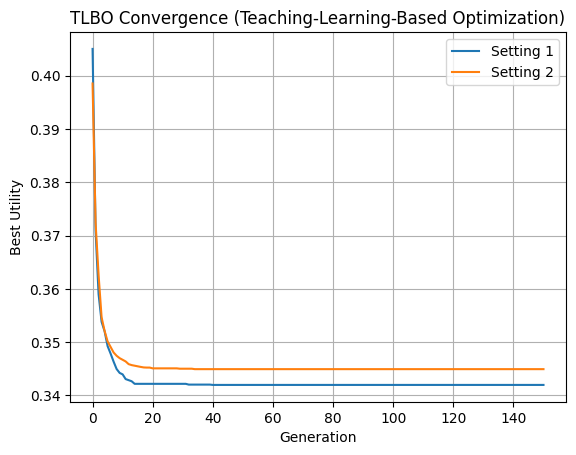

In [5]:
"""
TLBO (Teaching-Learning-Based Optimization) for Blockchain Configuration Optimization
Follows pseudo-algorithm:
- Initialize random population
- Evaluate fitness
- For each generation:
    - Teacher phase: Xnew = Xi + r*(Xbest - Tf*Xmean)
    - Accept if better
    - Learner phase: randomly select Xp, update based on comparison
    - Accept if better
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# TLBO parameters
POP_SIZE = 100             # population size (Np)
GENERATIONS = 150         # number of generations (T)

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        
        # Cost bounds
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X
        self.C_max = sum_all_M / self.t
        
        # Security bounds
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # Latency bounds
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (fitness) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        return (C_norm + eta_norm + L_norm) / 3


# ========================= TLBO IMPLEMENTATION =========================

def decode_solution(solution, problem):
    """
    Decode a real-coded solution (individual) into decision variables.
    Solution structure: [0] -> n (scaled [t, X])
                       [1..M] -> validator selection probabilities [0,1]
    Returns: (selected_validators, n, fitness)
    """
    # Decode n (first dimension)
    n_gene = solution[0]
    n = int(round(n_gene))
    n = max(problem.t, min(problem.X, n))
    
    # Decode validator mask: select indices where gene > 0.5
    mask = solution[1:1+problem.M]
    selected = [i for i, val in enumerate(mask) if val > 0.5]
    
    # Ensure v <= m <= M
    if len(selected) < problem.v:
        # Add missing validators from those not selected (highest mask values first)
        not_selected = [(i, mask[i]) for i in range(problem.M) if mask[i] <= 0.5]
        not_selected.sort(key=lambda x: x[1], reverse=True)
        needed = problem.v - len(selected)
        for i in range(min(needed, len(not_selected))):
            selected.append(not_selected[i][0])
    elif len(selected) > problem.M:
        selected = selected[:problem.M]
    
    # Remove duplicates and sort
    selected = sorted(set(selected))
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def initialize_population(problem, pop_size):
    """Initialize random population within bounds."""
    population = []
    for _ in range(pop_size):
        ind = [random.uniform(problem.t, problem.X)]  # n
        ind += [random.uniform(0, 1) for _ in range(problem.M)]  # validator genes
        population.append(ind)
    return population

def evaluate_population(population, problem):
    """Evaluate fitness for all individuals."""
    fitnesses = []
    for ind in population:
        _, _, fit = decode_solution(ind, problem)
        fitnesses.append(fit)
    return fitnesses

def bound_solution(solution, problem):
    """Clamp solution variables to their bounds."""
    bounds = [(problem.t, problem.X)] + [(0.0, 1.0) for _ in range(problem.M)]
    bounded = []
    for d, val in enumerate(solution):
        low, high = bounds[d]
        bounded.append(max(low, min(high, val)))
    return bounded

def tlbo(problem):
    """
    Teaching-Learning-Based Optimization algorithm.
    Returns best fitness, best solution (selected validators, n), and convergence history.
    """
    # Step 1-2: Initialize random population
    population = initialize_population(problem, POP_SIZE)
    # Step 3: Evaluate fitness
    fitness = evaluate_population(population, problem)
    
    # Best solution tracking
    best_idx = np.argmin(fitness)
    gbest = population[best_idx][:]
    gbest_fitness = fitness[best_idx]
    
    history = [gbest_fitness]
    
    # Main loop
    for t in range(GENERATIONS):
        # Compute mean of population (for Teacher phase)
        mean_pop = np.mean(population, axis=0).tolist()
        
        for i in range(POP_SIZE):
            # ----- Teacher Phase -----
            # Choose Xbest (global best)
            Xbest = gbest
            # Determine teaching factor Tf: 1 or 2 (random)
            Tf = random.choice([1, 2])
            # Random number r in [0,1]
            r = random.random()
            # Xnew = Xi + r*(Xbest - Tf*Xmean)
            Xi = population[i]
            Xnew = [Xi[d] + r * (Xbest[d] - Tf * mean_pop[d]) for d in range(len(Xi))]
            Xnew = bound_solution(Xnew, problem)
            # Evaluate new solution
            _, _, fnew = decode_solution(Xnew, problem)
            # Accept if better
            if fnew < fitness[i]:
                population[i] = Xnew
                fitness[i] = fnew
                # Update global best if needed
                if fnew < gbest_fitness:
                    gbest = Xnew[:]
                    gbest_fitness = fnew
            
            # ----- Learner Phase -----
            # Choose any random solution Xp (different from i)
            candidates = list(range(POP_SIZE))
            candidates.remove(i)
            p = random.choice(candidates)
            Xp = population[p]
            fp = fitness[p]
            # Determine Xnew based on comparison
            if fitness[i] < fp:  # current is better
                Xnew = [population[i][d] + r * (population[i][d] - Xp[d]) for d in range(len(Xi))]
            else:  # random is better
                Xnew = [population[i][d] - r * (population[i][d] - Xp[d]) for d in range(len(Xi))]
            Xnew = bound_solution(Xnew, problem)
            # Evaluate new solution
            _, _, fnew = decode_solution(Xnew, problem)
            # Accept if better
            if fnew < fitness[i]:
                population[i] = Xnew
                fitness[i] = fnew
                # Update global best if needed
                if fnew < gbest_fitness:
                    gbest = Xnew[:]
                    gbest_fitness = fnew
        
        history.append(gbest_fitness)
    
    # Decode final best solution
    selected, n, _ = decode_solution(gbest, problem)
    return gbest_fitness, (selected, n), history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run TLBO multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = tlbo(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('TLBO Convergence (Teaching-Learning-Based Optimization)')
    plt.legend()
    plt.grid(True)
    plt.show()


========== Setting 1 ==========
Best Utility = 0.339615
Average Utility = 0.339615 ± 0.000000
Best n = 50
Number of validators m = 25
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Time per run = 0.85 seconds

========== Setting 2 ==========
Best Utility = 0.342963
Average Utility = 0.342963 ± 0.000000
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 1.22 seconds


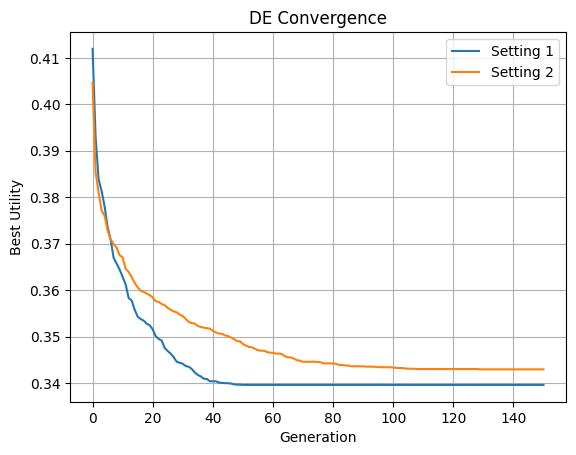

In [6]:
"""
DE (Differential Evolution) for Blockchain Configuration Optimization
Follows pseudo-algorithm:
- Initialize random population
- Evaluate fitness
- For each generation:
    - For each individual:
        - Generate donor vector using mutation (DE/rand/1)
        - Perform binomial crossover to create trial vector
    - For each individual:
        - Bound trial vector
        - Evaluate fitness
        - Greedy selection: replace if trial is better
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# DE parameters
POP_SIZE = 100             # population size (Np)
GENERATIONS = 150         # number of generations (T)
F = 0.8                   # mutation factor
PC = 0.8                  # crossover probability

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        
        # Cost bounds
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X
        self.C_max = sum_all_M / self.t
        
        # Security bounds
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # Latency bounds
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (fitness) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        return (C_norm + eta_norm + L_norm) / 3


# ========================= DE IMPLEMENTATION =========================

def decode_solution(solution, problem):
    """
    Decode a real-coded solution (individual) into decision variables.
    Solution structure: [0] -> n (scaled [t, X])
                       [1..M] -> validator selection probabilities [0,1]
    Returns: (selected_validators, n, fitness)
    """
    # Decode n (first dimension)
    n_gene = solution[0]
    n = int(round(n_gene))
    n = max(problem.t, min(problem.X, n))
    
    # Decode validator mask: select indices where gene > 0.5
    mask = solution[1:1+problem.M]
    selected = [i for i, val in enumerate(mask) if val > 0.5]
    
    # Ensure v <= m <= M
    if len(selected) < problem.v:
        # Add missing validators from those not selected (highest mask values first)
        not_selected = [(i, mask[i]) for i in range(problem.M) if mask[i] <= 0.5]
        not_selected.sort(key=lambda x: x[1], reverse=True)
        needed = problem.v - len(selected)
        for i in range(min(needed, len(not_selected))):
            selected.append(not_selected[i][0])
    elif len(selected) > problem.M:
        selected = selected[:problem.M]
    
    # Remove duplicates and sort
    selected = sorted(set(selected))
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def initialize_population(problem, pop_size):
    """Initialize random population within bounds."""
    population = []
    for _ in range(pop_size):
        ind = [random.uniform(problem.t, problem.X)]  # n
        ind += [random.uniform(0, 1) for _ in range(problem.M)]  # validator genes
        population.append(ind)
    return population

def evaluate_population(population, problem):
    """Evaluate fitness for all individuals."""
    fitnesses = []
    for ind in population:
        _, _, fit = decode_solution(ind, problem)
        fitnesses.append(fit)
    return fitnesses

def bound_solution(solution, problem):
    """Clamp solution variables to their bounds."""
    bounds = [(problem.t, problem.X)] + [(0.0, 1.0) for _ in range(problem.M)]
    bounded = []
    for d, val in enumerate(solution):
        low, high = bounds[d]
        bounded.append(max(low, min(high, val)))
    return bounded

def de(problem):
    """
    Differential Evolution algorithm (DE/rand/1/bin).
    Returns best fitness, best solution (selected validators, n), and convergence history.
    """
    # Step 1-2: Initialize random population and evaluate
    population = initialize_population(problem, POP_SIZE)
    fitness = evaluate_population(population, problem)
    
    # Best solution tracking
    best_idx = np.argmin(fitness)
    gbest = population[best_idx][:]
    gbest_fitness = fitness[best_idx]
    history = [gbest_fitness]
    
    # Main loop
    for t in range(GENERATIONS):
        # Create trial vectors for each individual
        trial_pop = []
        trial_fitness = []
        
        for i in range(POP_SIZE):
            # ----- Mutation: DE/rand/1 -----
            # Select three distinct random indices different from i
            candidates = list(range(POP_SIZE))
            candidates.remove(i)
            r1, r2, r3 = random.sample(candidates, 3)
            Xr1 = population[r1]
            Xr2 = population[r2]
            Xr3 = population[r3]
            # Donor vector V = Xr1 + F*(Xr2 - Xr3)
            V = [Xr1[d] + F * (Xr2[d] - Xr3[d]) for d in range(len(Xr1))]
            
            # ----- Crossover: binomial -----
            # Generate trial vector U
            U = []
            # Randomly select at least one dimension from V
            j_rand = random.randint(0, len(V)-1)
            for d in range(len(V)):
                if random.random() < PC or d == j_rand:
                    U.append(V[d])
                else:
                    U.append(population[i][d])
            
            # Bound the trial vector
            U = bound_solution(U, problem)
            trial_pop.append(U)
            # Evaluate later (after all trial vectors created, to match algorithm structure)
        
        # Evaluate all trial vectors
        trial_fitness = []
        for U in trial_pop:
            _, _, fit = decode_solution(U, problem)
            trial_fitness.append(fit)
        
        # ----- Greedy selection -----
        for i in range(POP_SIZE):
            if trial_fitness[i] < fitness[i]:
                population[i] = trial_pop[i]
                fitness[i] = trial_fitness[i]
                # Update global best
                if fitness[i] < gbest_fitness:
                    gbest = population[i][:]
                    gbest_fitness = fitness[i]
        
        history.append(gbest_fitness)
    
    # Decode final best solution
    selected, n, _ = decode_solution(gbest, problem)
    return gbest_fitness, (selected, n), history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run DE multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = de(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('DE Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()


========== Setting 1 ==========
Best Utility = 0.352977
Average Utility = 0.362574 ± 0.004263
Best n = 50
Number of validators m = 22
Selected validators = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 22, 23, 24]
Time per run = 1.17 seconds

========== Setting 2 ==========
Best Utility = 0.358753
Average Utility = 0.367675 ± 0.003687
Best n = 50
Number of validators m = 33
Selected validators = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 25, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39]
Time per run = 1.35 seconds


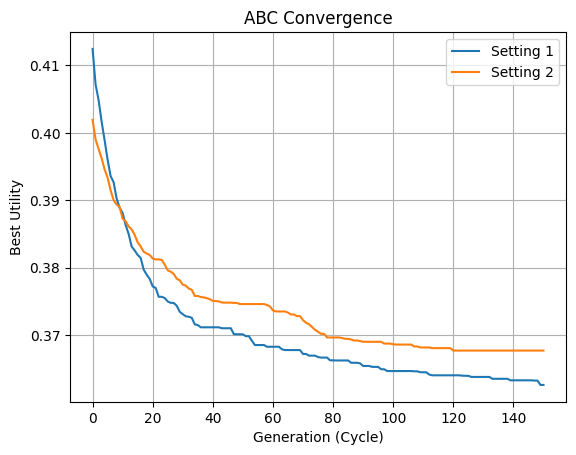

In [7]:
"""
ABC (Artificial Bee Colony) for Blockchain Configuration Optimization
Follows the three-phase pseudocode:
- Employed Bee Phase: modify one dimension with a random partner
- Onlooker Bee Phase: probabilistic selection + same modification
- Scout Bee Phase: replace exhausted sources with random ones
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# ABC parameters
POP_SIZE = 100             # number of food sources (Np) = number of employed/onlooker bees
GENERATIONS = 150         # number of cycles (T)
LIMIT = 10                # trial limit for scout bee phase (abandonment threshold)

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition: bounds, evaluation, normalization."""
    
    def __init__(self, setting=1):
        if setting == 1:
            self.M = 25
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [250.74, 187.36, 138.91, 245.20, 271.70, 276.80, 119.32, 194.45, 213.02, 138.59,
                      207.21, 215.94, 236.32, 203.08, 145.41, 264.83, 286.12, 123.30, 242.89, 121.47,
                      198.76, 254.19, 167.43, 289.05, 132.88]
        else:
            self.M = 40
            self.v = 5
            self.t = 50
            self.X = 500
            self.x = [121.12, 259.89, 198.40, 234.00, 272.30, 134.32, 157.55, 288.65, 210.58, 255.98,
                      249.03, 201.28, 298.93, 157.16, 125.26, 167.22, 261.86, 211.60, 184.22, 153.01,
                      116.73, 241.46, 201.56, 290.00, 218.31, 232.87, 104.61, 268.79, 185.63, 115.13,
                      236.16, 102.55, 259.15, 226.24, 100.15, 142.94, 199.64, 221.28, 150.30, 104.61]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)
        sorted_desc = sorted(self.x, reverse=True)
        
        # Cost bounds
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X
        self.C_max = sum_all_M / self.t
        
        # Security bounds
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # Latency bounds
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """
        Compute utility (objective) for a given solution.
        Lower utility is better.
        """
        m = len(selected_indices)
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        C = sum(self.x[i] for i in selected_indices) / n
        eta = THETA * (m ** Q)
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        return (C_norm + eta_norm + L_norm) / 3


# ========================= ABC IMPLEMENTATION =========================

def decode_solution(solution, problem):
    """
    Decode a real-coded solution (food source) into decision variables.
    Structure: [0] -> n (scaled [t, X])
               [1..M] -> validator selection probabilities [0,1]
    Returns: (selected_validators, n, utility)
    """
    # Decode n
    n_gene = solution[0]
    n = int(round(n_gene))
    n = max(problem.t, min(problem.X, n))
    
    # Decode validator mask: select indices where gene > 0.5
    mask = solution[1:1+problem.M]
    selected = [i for i, val in enumerate(mask) if val > 0.5]
    
    # Ensure v <= m <= M
    if len(selected) < problem.v:
        not_selected = [(i, mask[i]) for i in range(problem.M) if mask[i] <= 0.5]
        not_selected.sort(key=lambda x: x[1], reverse=True)
        needed = problem.v - len(selected)
        for i in range(min(needed, len(not_selected))):
            selected.append(not_selected[i][0])
    elif len(selected) > problem.M:
        selected = selected[:problem.M]
    
    selected = sorted(set(selected))
    utility = problem.evaluate(selected, n)
    return selected, n, utility

def objective_to_fitness(utility):
    """Convert utility (to minimize) to fitness (to maximize)."""
    if utility == float('inf'):
        return 0.0
    return 1.0 / (1.0 + utility)

def initialize_food_sources(problem, pop_size):
    """Initialize random food sources within bounds."""
    sources = []
    for _ in range(pop_size):
        ind = [random.uniform(problem.t, problem.X)]  # n
        ind += [random.uniform(0, 1) for _ in range(problem.M)]
        sources.append(ind)
    return sources

def evaluate_sources(sources, problem):
    """Compute utility and fitness for all food sources."""
    utilities = []
    for src in sources:
        _, _, u = decode_solution(src, problem)
        utilities.append(u)
    fitnesses = [objective_to_fitness(u) for u in utilities]
    return utilities, fitnesses

def bound_solution(solution, problem):
    """Clamp solution variables to their bounds."""
    bounds = [(problem.t, problem.X)] + [(0.0, 1.0) for _ in range(problem.M)]
    bounded = []
    for d, val in enumerate(solution):
        low, high = bounds[d]
        bounded.append(max(low, min(high, val)))
    return bounded

def modify_solution(source, partner, j, phi, problem):
    """
    Modify the j-th variable of source using partner:
    new_val = source[j] + phi * (source[j] - partner[j])
    Then bound and return new solution.
    """
    new_solution = source[:]
    new_val = source[j] + phi * (source[j] - partner[j])
    low, high = (problem.t, problem.X) if j == 0 else (0.0, 1.0)
    new_val = max(low, min(high, new_val))
    new_solution[j] = new_val
    return new_solution

def abc(problem):
    """
    Artificial Bee Colony algorithm.
    Returns best utility, best solution (selected validators, n), and convergence history.
    """
    # Initialize
    sources = initialize_food_sources(problem, POP_SIZE)
    utilities, fitnesses = evaluate_sources(sources, problem)
    trial = [0] * POP_SIZE
    
    # Track global best
    best_idx = np.argmin(utilities)
    best_utility = utilities[best_idx]
    best_solution = sources[best_idx][:]
    history = [best_utility]
    
    # Main loop
    for cycle in range(GENERATIONS):
        # ----- Employed Bee Phase -----
        for i in range(POP_SIZE):
            # Random partner (different index)
            partners = list(range(POP_SIZE))
            partners.remove(i)
            p = random.choice(partners)
            # Random variable dimension
            j = random.randint(0, problem.M)  # 0 for n, 1..M for validator genes
            # Random phi in [-1, 1]
            phi = random.uniform(-1, 1)
            # Create new solution
            new_src = modify_solution(sources[i], sources[p], j, phi, problem)
            # Evaluate new solution
            _, _, new_util = decode_solution(new_src, problem)
            new_fit = objective_to_fitness(new_util)
            # Greedy selection (maximization)
            if new_fit > fitnesses[i]:
                sources[i] = new_src
                utilities[i] = new_util
                fitnesses[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1
        
        # ----- Onlooker Bee Phase -----
        # Compute probabilities proportional to fitness
        total_fit = sum(fitnesses)
        if total_fit == 0:
            probs = [1.0/POP_SIZE] * POP_SIZE
        else:
            probs = [f / total_fit for f in fitnesses]
        
        m = 0  # number of onlookers placed
        n = 0  # index of current food source
        while m < POP_SIZE:
            r = random.random()
            if r < probs[n]:
                # Select random partner (different from n)
                partners = list(range(POP_SIZE))
                partners.remove(n)
                p = random.choice(partners)
                # Random variable dimension
                j = random.randint(0, problem.M)
                phi = random.uniform(-1, 1)
                # Create new solution
                new_src = modify_solution(sources[n], sources[p], j, phi, problem)
                # Evaluate
                _, _, new_util = decode_solution(new_src, problem)
                new_fit = objective_to_fitness(new_util)
                # Greedy selection
                if new_fit > fitnesses[n]:
                    sources[n] = new_src
                    utilities[n] = new_util
                    fitnesses[n] = new_fit
                    trial[n] = 0
                else:
                    trial[n] += 1
                m += 1
            n += 1
            if n >= POP_SIZE:
                n = 0
        
        # ----- Scout Bee Phase -----
        for i in range(POP_SIZE):
            if trial[i] > LIMIT:
                # Replace with random food source
                new_src = [random.uniform(problem.t, problem.X)] + \
                          [random.uniform(0, 1) for _ in range(problem.M)]
                _, _, new_util = decode_solution(new_src, problem)
                new_fit = objective_to_fitness(new_util)
                sources[i] = new_src
                utilities[i] = new_util
                fitnesses[i] = new_fit
                trial[i] = 0
        
        # Update global best
        current_best_idx = np.argmin(utilities)
        if utilities[current_best_idx] < best_utility:
            best_utility = utilities[current_best_idx]
            best_solution = sources[current_best_idx][:]
        history.append(best_utility)
    
    # Decode final best solution
    selected, n, _ = decode_solution(best_solution, problem)
    return best_utility, (selected, n), history


# ========================= RUN & VISUALIZATION =========================

def run_for_setting(setting, runs=20):
    """Run ABC multiple times for a given setting and report statistics."""
    problem = BlockchainConfig(setting)
    best_vals = []
    histories = []
    best_global = None
    best_global_util = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_util, best_sol, hist = abc(problem)
        best_vals.append(best_util)
        histories.append(hist)
        if best_util < best_global_util:
            best_global_util = best_util
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n = best_global
    print(f"\n========== Setting {setting} ==========")
    print(f"Best Utility = {best_global_util:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0)

if __name__ == "__main__":
    # Run both settings and plot convergence
    for s in [1, 2]:
        avg_history = run_for_setting(s, runs=20)
        plt.plot(avg_history, label=f'Setting {s}')
    
    plt.xlabel('Generation (Cycle)')
    plt.ylabel('Best Utility')
    plt.title('ABC Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()